Modern deep learning frameworks abstract away much of the training process. This notebook builds on the work from previous notebooks in the series.

Here, I move to binary classification using the Breast Cancer Wisconsin dataset. I introduce the sigmoid activation function and binary cross-entropy loss, demonstrate overfitting using a proper train/test split, and explore two regularization techniques—L2 regularization and dropout—to show how they improve generalization.

# Importing libraries

In [1]:
# importing libraries
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # heatmap for corr matrix

from dataclasses import dataclass

# as explained in previous notebook
# it is better to use  sklearn train_test_split
# because of it's ability to split in a stratified fashion
from sklearn.model_selection import train_test_split

# Helper functions and classes

In [2]:
# --- Colab setup (ignore if running locally) ---
if not Path("/content/ml-from-scratch").exists():
  !git clone https://github.com/vmirchev/ml-from-scratch.git

Cloning into 'ml-from-scratch'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 59 (delta 23), reused 48 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 380.08 KiB | 8.26 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [3]:
import sys

# --- Colab setup (ignore if running locally) ---
# add the project root to the system path if not already present
project_root = Path("/content/ml-from-scratch")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.layers import BaseLayer, LinearLayer
from src.activations import ReLU, softmax
from src.preprocessing import ZScoreNormalization
from src.utils import set_seeds, create_batches, plot_training_curves

In [4]:
# set seeds for reproducibility
seed = 42
set_seeds(seed)

In [5]:
# this notebook will use xavier weight initalization
# works better with sigmoid
# weight initializations will be a subject of future notebook
WEIGHT_INIT = "xavier"

# Code refactor and helper functions

Before I introduce anything new, a bit of preparation is needed. I need to redefine the model class, because I need to be able to notfy some layers of we are training or evaluating.

In [6]:
class Model:
  def __init__(self, layers=None):
    self.layers = []
    if layers:
        self.add_all(layers)

  def add(self, layer):
    self.layers.append(layer)

  def add_all(self, layers):
    self.layers.extend(layers)

  def forward(self, x):
    for layer in self.layers:
        x = layer.forward(x)
    return x

  def backward(self, grad):
    # iterate backward through the layers
    for layer in reversed(self.layers):
        grad = layer.backward(grad)
    return grad

  def step(self, lr):
    # call step only on layers that have learnable parameters
    for layer in self.layers:
        if hasattr(layer, 'step'):
            layer.step(lr)

  # new train and eval functions to update layers
  def train(self):
    for layer in self.layers:
      layer.train()

  def eval(self):
    for layer in self.layers:
      layer.eval()

In [7]:
# small helper function
def get_total_weight_l2_norm(model):
  total = 0.0
  for layer in model.layers:
    if isinstance(layer, LinearLayer):
      total += np.sum(layer.w ** 2)
  return total

# Dataset


The Breast Cancer Wisconsin dataset is a collection of medical diagnostic data derived from digitized images of fine needle aspirates (FNAs) of breast masses. Maintained in the UCI Machine Learning Repository, it is among the most widely used benchmark datasets for machine learning in healthcare and pattern recognition.

Why this dataset is a good fit for this notebook:
- ~570 samples - easy to overfit
- 30 features - good for L2 impact
- Binary classification - new loss function
- We will be working with a clean, widely recognized tabular dataset

In [8]:
candidate_paths = [
    Path("ml-from-scratch") / "data" / "breast_cancer_data.csv",
    Path("data") / "breast_cancer_data.csv",
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find breast_cancer_data.csv")

df = pd.read_csv(csv_path)
print(f"Successfully loaded '{csv_path}' into a pandas DataFrame.")
df.head()

Successfully loaded 'ml-from-scratch/data/breast_cancer_data.csv' into a pandas DataFrame.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Let's plot a correlation matrix to check if there is correlation between different features.

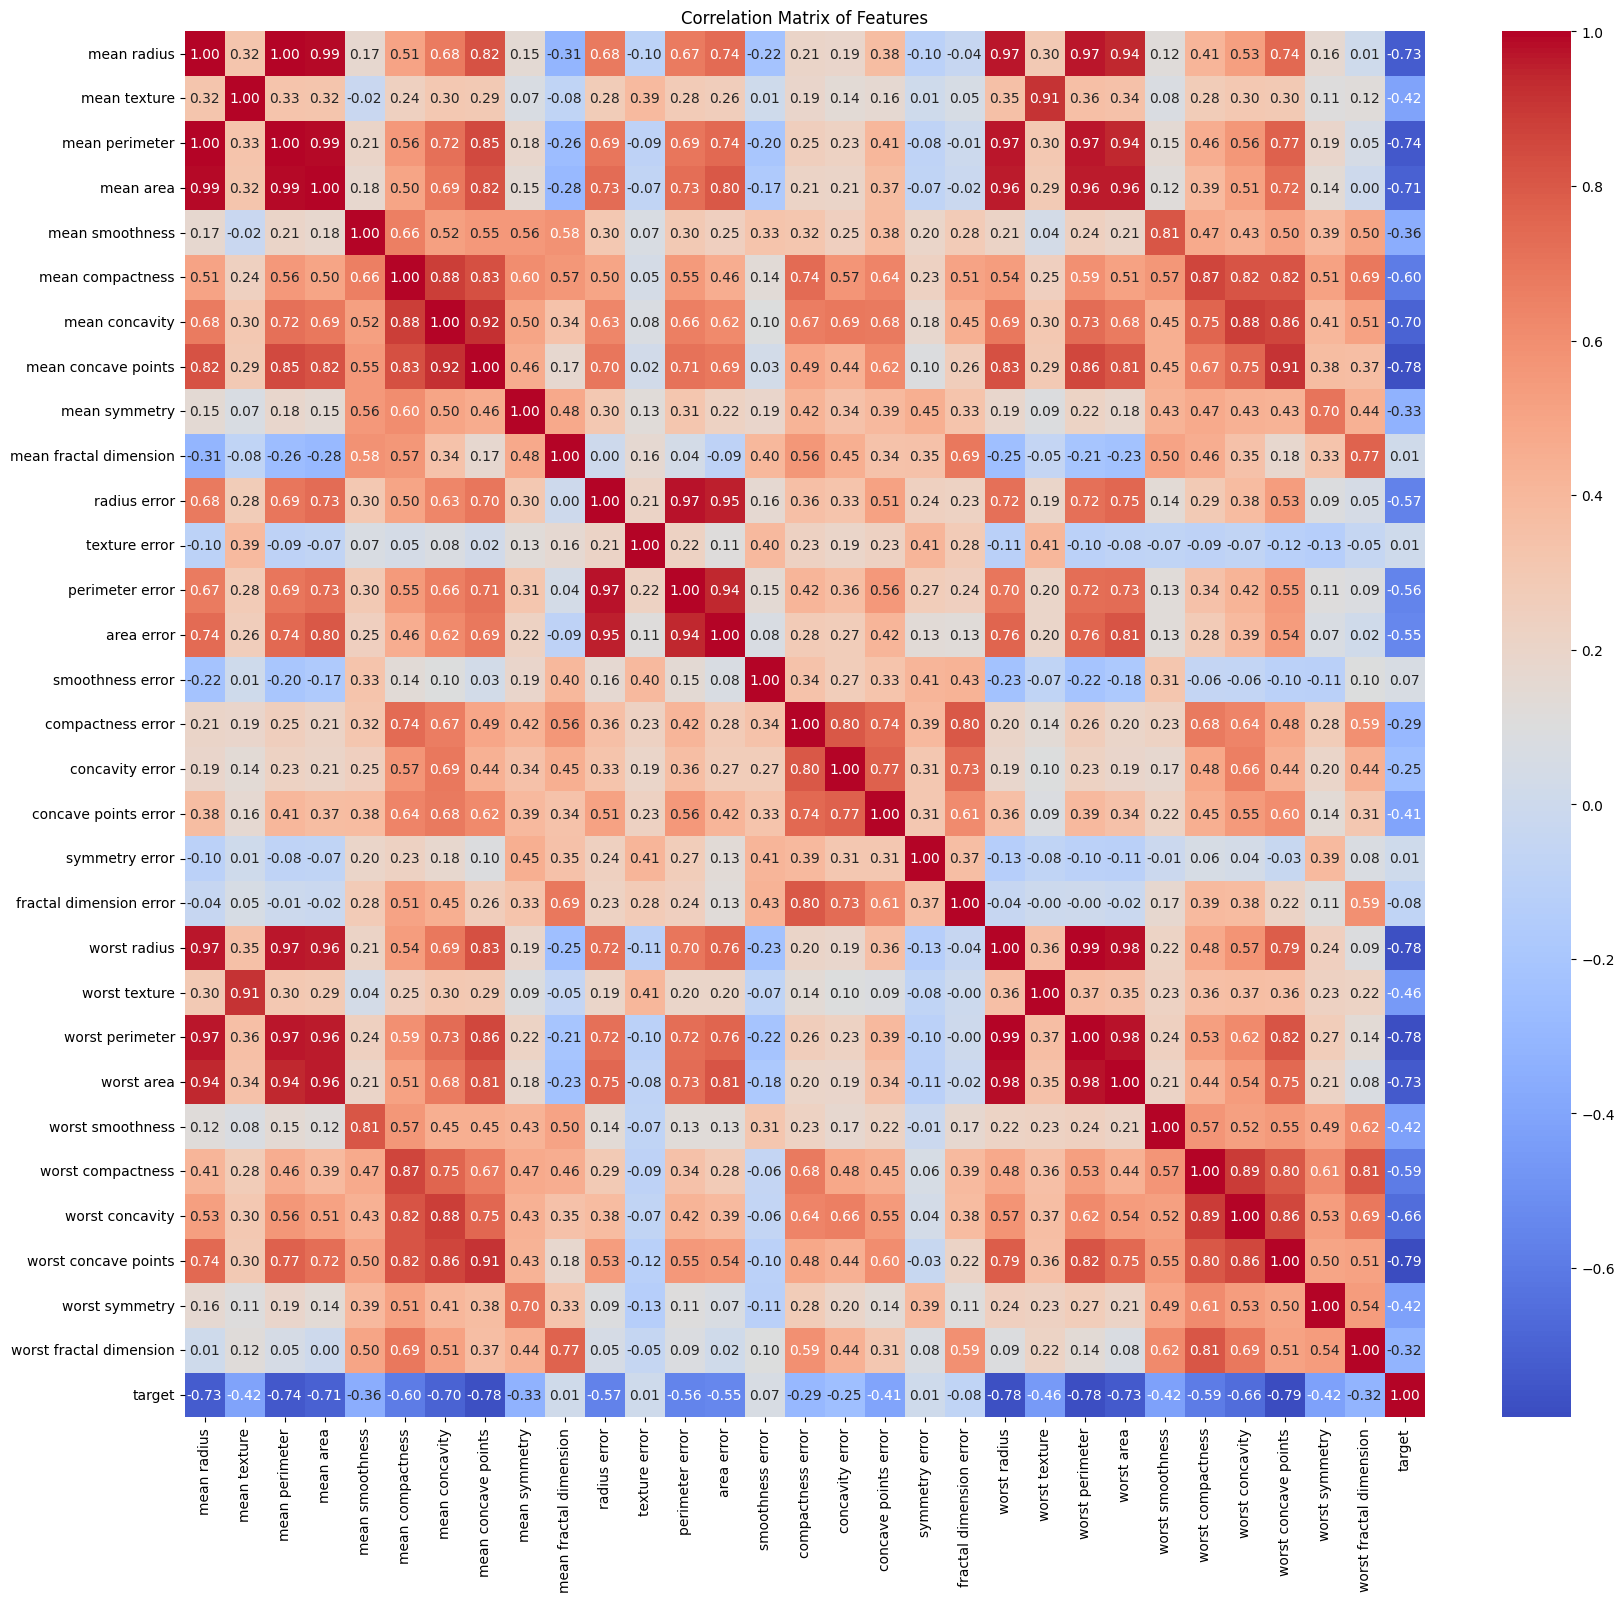

In [9]:
plt.figure(figsize=(20, 18))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

As expected, there is a clear correlation between some of the features and the target variable. In a future experiment, I may try removing less informative features such as "symmetry error", but for this notebook I will keep all features.

## Train-Test Split

Since I'm using a stratified split, I'll rely on scikit-learn's train_test_split rather than implementing it manually.

This is the only exception in the series where I use this function for convenience.

In [10]:
features = df.drop('target', axis=1).values
targets = df['target'].values

# use sklearn train test split with stratify and random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(features, targets,
                                                    test_size=0.2,
                                                    random_state=seed,
                                                    stratify=targets)

print(f"Training set features shape: {X_train.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Test set features shape: {X_test.shape}")
print(f"Test set target shape: {y_test.shape}")

Training set features shape: (455, 30)
Training set target shape: (455,)
Test set features shape: (114, 30)
Test set target shape: (114,)


In [11]:
# avoiding data leackage fit to train, transform test
data_normalization = ZScoreNormalization()
X_train = data_normalization.fit_transform(X_train)
X_test = data_normalization.transform(X_test)

# Sigmoid activation function

Since this is a binary classification problem with only two target classes, I will use and try to explain **binary cross-entropy**, which is the binary case of cross-entropy.

For that to work we first need to define a **sigmoid function**.

The sigmoid function is a mathematical function that takes any real number (from $−∞$ to $+∞$) and squashes it into a value between 0 and 1.

The formula is:
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

In [12]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

To test it, I generate 100 values between -5 and 5 and run them through a sigmoid activation function. As expected the results of the function are between 0 and 1.

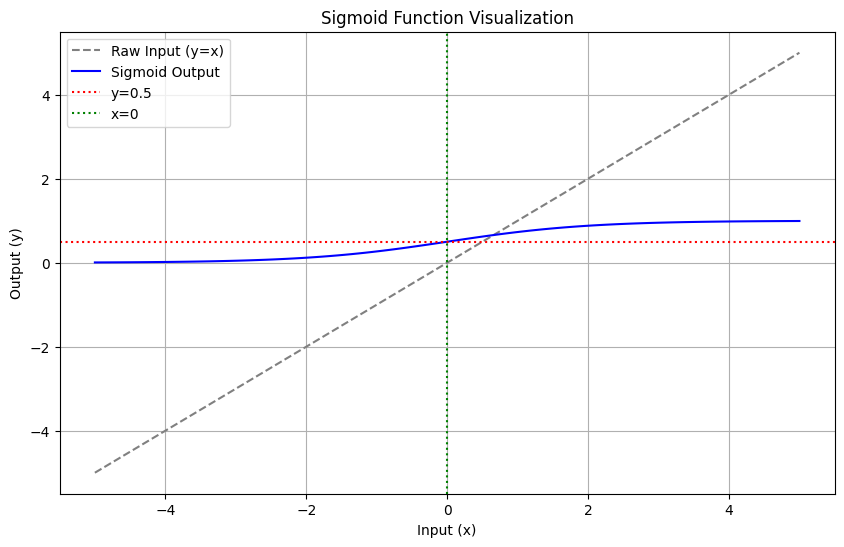

In [13]:
# generate 100 data points
x_values = np.linspace(-5, 5, 100)
y_values_sigmoid = sigmoid(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, x_values, label='Raw Input (y=x)', linestyle='--', color='gray')
plt.plot(x_values, y_values_sigmoid, label='Sigmoid Output', color='blue')
plt.title('Sigmoid Function Visualization')
plt.xlabel('Input (x)')
plt.ylabel('Output (y)')
plt.axhline(0.5, color='red', linestyle=':', label='y=0.5')
plt.axvline(0, color='green', linestyle=':', label='x=0')
plt.grid(True)
plt.legend()
plt.show()

As we have seen, models produce logits, which can take any real value. The sigmoid function transforms these logits into probabilities between 0 and 1.

To convert probabilities into predictions, we usually apply a **decision threshold** of 0.5: values above 0.5 are classified as class 1, and values below 0.5 as class 0.

# Binary Cross Entropy

The logic behind Binary Cross Entropy is similar to cross-entropy in the multiclass case.
We pass the logits through a sigmoid activation function to obtain probabilities and train the model to assign high probability to the correct class.

It comes from Probability Theory, from [Bernoulli distribution](https://en.wikipedia.org/wiki/Bernoulli_distribution) to be more specific. It is a discrete probability distribution modeling a single experiment with only two outcomes: "success" (value 1) with probability $(p)$, and "failure" (value 0) with probability $q = 1-p$.

The likelihood formula in this case:
$$P(y \mid p) = p^{y}(1 - p)^{1 - y}$$

Here is the log likelihood:

$$
\log P(y \mid p) = y \log p + (1 - y)\log(1 - p)
$$

**Binary cross-entropy** is the negative average log-likelihood over the dataset.

$$\text{BCE}=-\frac{1}{N}\sum _{i=1}^{N}\left[y_{i}\log (p_{i})+(1-y_{i})\log (1-p_{i})\right]$$

Where:
- $N$: Number of samples
- $y_i$: Ground truth label (0 or 1)
- $p_i$: Predicted probability for the positive class (output of sigmoid)

Thus, Binary Cross Entropy is simply the negative log-likelihood of a Bernoulli-distributed target.

## Why do we take the log?

When working with probabilities, we often need to multiply many small numbers together, which can make them extremely small and lead to numerical instability. To fix this, we take the logarithm, which turns multiplication into addition. This makes the computations more stable and easier to optimize, which simplifies gradient descent.

Besides the mathematical advantages, using the log also leads to better learning behavior. Predicting 0.9 for the correct class results in a small penalty, while predicting 0.01 leads to a very large penalty. This helps guide the model during training by strongly discouraging confident wrong predictions.

In [14]:
class BinaryCrossEntropyLoss:
  EPSILON = 1e-9

  def __init__(self):
    self.y_true = None
    self.sigmoid_output = None
    self.batch_size = 0

  def forward(self, logits, y_true):
    # Ensure y_true is a 2D array for consistent operations, typically 0 or 1
    self.y_true = np.asarray(y_true).reshape(-1, 1)
    self.batch_size = y_true.shape[0]


    # apply sigmoid activation to get probabilities

    # naive sigmoid
    #self.sigmoid_output = 1 / (1 + np.exp(-logits))

    # clipped sigmoid for numerical stability
    self.sigmoid_output = 1 / (1 + np.exp(-np.clip(logits, -50, 50)))

    # clip probabilities for numerical stability
    clipped_sigmoid_output = np.clip(self.sigmoid_output, self.EPSILON, 1.0 - self.EPSILON)

    # calculate binary cross-entropy loss
    loss = -np.mean(self.y_true * np.log(clipped_sigmoid_output) + (1 - self.y_true) * np.log(1 - clipped_sigmoid_output))

    return loss

  def backward(self):
    # dL/d(logits) = (sigmoid_output - y_true) / batch_size
    grad_logits = (self.sigmoid_output - self.y_true) / self.batch_size
    return grad_logits

# Overfitting

Overfitting occurs when a model learns the training data too closely and fails to generalize well to unseen data. This is usually visible when the training loss continues to decrease while the test loss increases, or when performance on unseen data becomes worse.

First I will define a envaluate function, then I will show an example of overfitting.

In [15]:
@dataclass
class TrainingConfig:
  epochs: int
  batch_size: int
  lr: float
  scenario_name: str = ""
  threshold: float = 0.5

  debug_print: bool = False
  show_plot:bool = False

In [16]:
def evaluate_binary_classification_model(model, loss_fn, X_test, y_test, cfg: TrainingConfig):
  model.eval() # Set model to evaluation mode

  epoch_test_loss_sum = 0
  epoch_test_correct = 0
  epoch_test_total = 0

  for X_batch_test, y_batch_test in create_batches(X_test, y_test, cfg.batch_size, shuffle=False):
      # set is_training to False for evaluation
      logits_test = model.forward(X_batch_test)

      batch_test_loss = loss_fn.forward(logits_test, y_batch_test)
      epoch_test_loss_sum += batch_test_loss * len(y_batch_test) # Corrected from batch_loss

      # convert probabilities to binary predictions for accuracy calculation
      test_predictions = (loss_fn.sigmoid_output >= cfg.threshold).astype(int).flatten()
      epoch_test_correct += np.sum(test_predictions == y_batch_test)
      epoch_test_total += len(y_batch_test)

  test_loss = epoch_test_loss_sum / epoch_test_total
  test_accuracy = epoch_test_correct / epoch_test_total
  return test_loss, test_accuracy

In [17]:
def train_model(model, loss_fn, X_train, y_train, X_test, y_test, cfg: TrainingConfig):
  train_losses = []
  train_accuracies = []

  test_losses = []
  test_accuracies = []

  for epoch in range(cfg.epochs):

    # training phase
    model.train()
    epoch_train_loss_sum = 0
    epoch_train_correct = 0
    epoch_train_total = 0

    for X_batch, y_batch in create_batches(X_train, y_train, cfg.batch_size):

      # forward pass
      logits = model.forward(X_batch)

      # calculate the loss
      batch_loss = loss_fn.forward(logits, y_batch)
      epoch_train_loss_sum += batch_loss * len(y_batch)

      # calculate accuracy
      # convert probabilities to binary predictions
      predictions = (loss_fn.sigmoid_output >= cfg.threshold).astype(int).flatten()
      epoch_train_correct += np.sum(predictions == y_batch)

      # update total count
      epoch_train_total += len(y_batch)

      # derivative of loss fn
      grad_logits = loss_fn.backward()

      # gradient descent
      model.backward(grad_logits)

      model.step(cfg.lr)

    train_losses.append(epoch_train_loss_sum / epoch_train_total)
    train_accuracies.append(epoch_train_correct / epoch_train_total)

    # make an evaluation run in each epoch
    model.eval()
    test_loss, test_accuracy = evaluate_binary_classification_model(model, loss_fn, X_test, y_test, cfg)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

  if cfg.show_plot:
    print(cfg.scenario_name)
    plot_training_curves(train_losses, train_accuracies, test_losses, test_accuracies)

  if cfg.debug_print:
    print(f"Final train loss: {train_losses[-1]:.4f}")
    print(f"Final train accuracy: {train_accuracies[-1]:.4f}")
    print(f"Final test loss: {test_losses[-1]:.4f}")
    print(f"Final test accuracy: {test_accuracies[-1]:.4f}")

    print(f"Generalization gap: {test_losses[-1] - train_losses[-1]:.4f}")
    if hasattr(model, 'layers'):
        l2_norm = get_total_weight_l2_norm(model)
        print(f"Weight L2 norm: {l2_norm:.4f}")

  return train_losses, train_accuracies, test_losses, test_accuracies

No Regularization (Model 0)


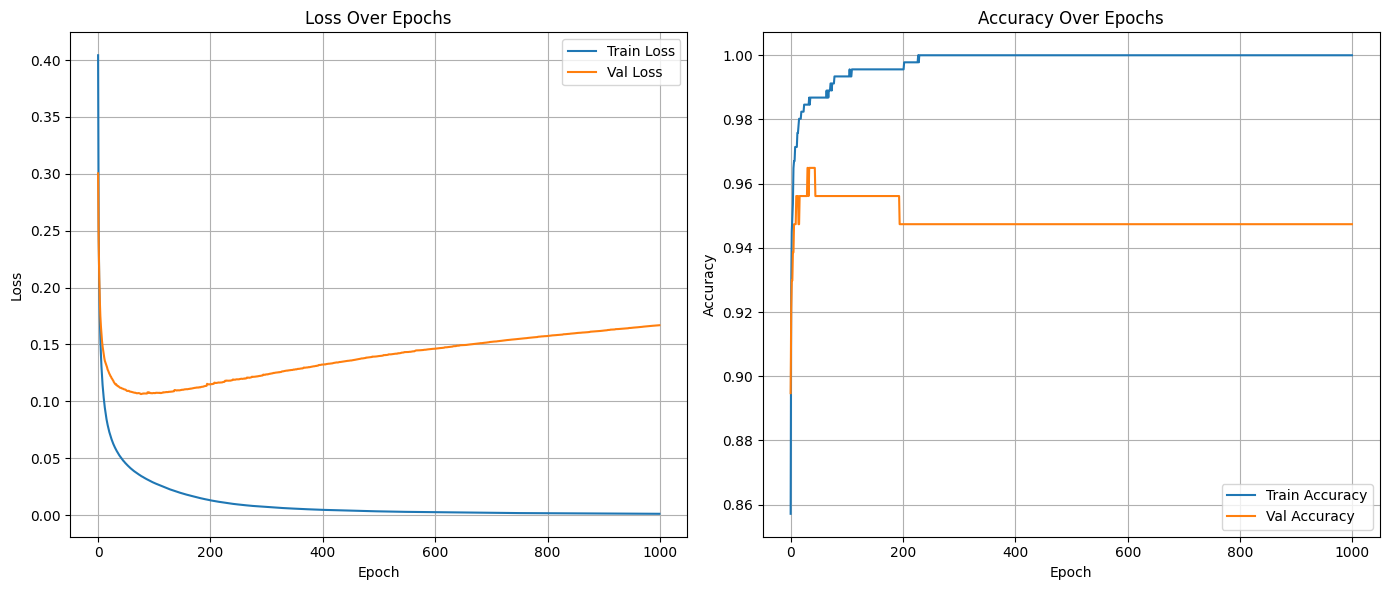

Final train loss: 0.0011
Final train accuracy: 1.0000
Final test loss: 0.1669
Final test accuracy: 0.9474
Generalization gap: 0.1658
Weight L2 norm: 216.6356


In [18]:
# create model
layers = [LinearLayer(in_features=30, out_features=64),
ReLU(),
LinearLayer(in_features=64, out_features=32),
ReLU(),
LinearLayer(in_features=32, out_features=1)]

model0 = Model(layers)

# define a loss function
loss_fn = BinaryCrossEntropyLoss()

# create a TrainingConfig instance
training_cfg_model0 = TrainingConfig(
    epochs=1000,
    batch_size=16,
    lr=0.01,
    scenario_name="No Regularization (Model 0)",
    debug_print=True,
    show_plot=True
)

# train and evaluate the model
train_losses, train_accuracies, test_losses, test_accuracies = train_model(
    model0, loss_fn, X_train, y_train, X_test, y_test, training_cfg_model0
)

We can clearly see a lot of overfitting. This is noticeable by the training loss going really close to 0 and the test loss going up and down and then flattens around one. It is also visible in the accuracy graph with training accuracy reaching 100%, while test accuracy around 91%.

# Why does overfitting happen

There are four common reasons.


- Not enough training data - for example it is really hard to differentiate 3 different cars categories with a dataset of 10 photos in total.

- Model complexity - the model may be too deep for the current dataset.

- Noisy or dirty data - with real-world data usually there are a lot of missing values, wrong labels. Sometimes the device used to collect data is unreliable. All of this influences how the model learns.

- Overtraining - when we train for a lot of time, there is a good chance the model will just memorize the training data.

## Solutions

- Collecting more data, when that is feasible.

- Sometimes simplifying the model structure helps. Especially if a pretrained model is used for a simple problem.

- Data cleaning is very useful, but can be time consuming.

- Using early stopping, for example by monitoring validation loss and stopping training when it has not improved for a fixed number of epochs.

- Use **regularization** techniques that help the model generalize better.


# L2 Regularization or Weight Decay

> L2 regularization penalizes large weights by adding a term proportional to the squared magnitude of the parameters. In practice, this encourages the model to keep weights smaller, which often improves generalization and reduces overfitting.

In simpler terms, L2 discourages the network from relying on very large weight values. It does not force weights to become exactly zero, but it pushes them toward smaller magnitudes.

The L2 Formula is:

$$Cost = \text{Loss} + \lambda \sum_{i=1}^{n} w_i^2$$

The intuition behind it is:

> Big weights are expensive — keep them small unless absolutely necessary

# My L2 implementation

As previously shown L2 adds penalty term to the loss function. But, in a from scratch implementation this is less convenient in this implementation as the loss function will need to have info for all the weights in the model, and since the loss function must be tied to features and targets, not model architecture it seems inadequate to implement it with the loss.

My approach is to account for it in the linear layer during backpropagation by adding the L2 gradient directly to the weight gradients.

$$
\frac{\partial}{\partial W} (\lambda \|W\|^2) = 2\lambda W
$$

This results in the following update:

$$
\frac{\partial \mathscr{L}}{\partial W} = \frac{\partial \mathscr{L}_{data}}{\partial W} + 2\lambda W
$$

This is mathematically equivalent to adding L2 regularization to the loss, but a lot simpler to implement.


In [19]:
class LinearLayer(BaseLayer):
  def __init__(self, in_features:int, out_features:int, initialization: str = "he", l2_lambda = 0.0):

    if initialization == "he":
      scale = np.sqrt(2.0 / in_features)
    elif initialization == "xavier":
      scale = np.sqrt(1.0 / in_features)
    elif initialization == "standard":
      scale = 0.01
    else:
      raise ValueError(f"Unknown init: {initialization}")

    self.w = np.random.randn(in_features, out_features) * scale
    self.b = np.zeros((1, out_features)) # we need one bias per output feature

    self.l2_lambda = l2_lambda

  def forward(self, x):
    self.x = x
    return x @ self.w + self.b

  def backward(self, dout):
    self.dw = self.x.T @ dout
    self.db = np.sum(dout, axis=0, keepdims=True)

    # l2 regularization aka weight decay
    self.dw += 2 * self.l2_lambda * self.w

    dx = dout @ self.w.T
    return dx

  def step(self, lr):
    self.w = self.w - (self.dw * lr)
    self.b = self.b - (self.db * lr)


L2 Regularization (Model 1)


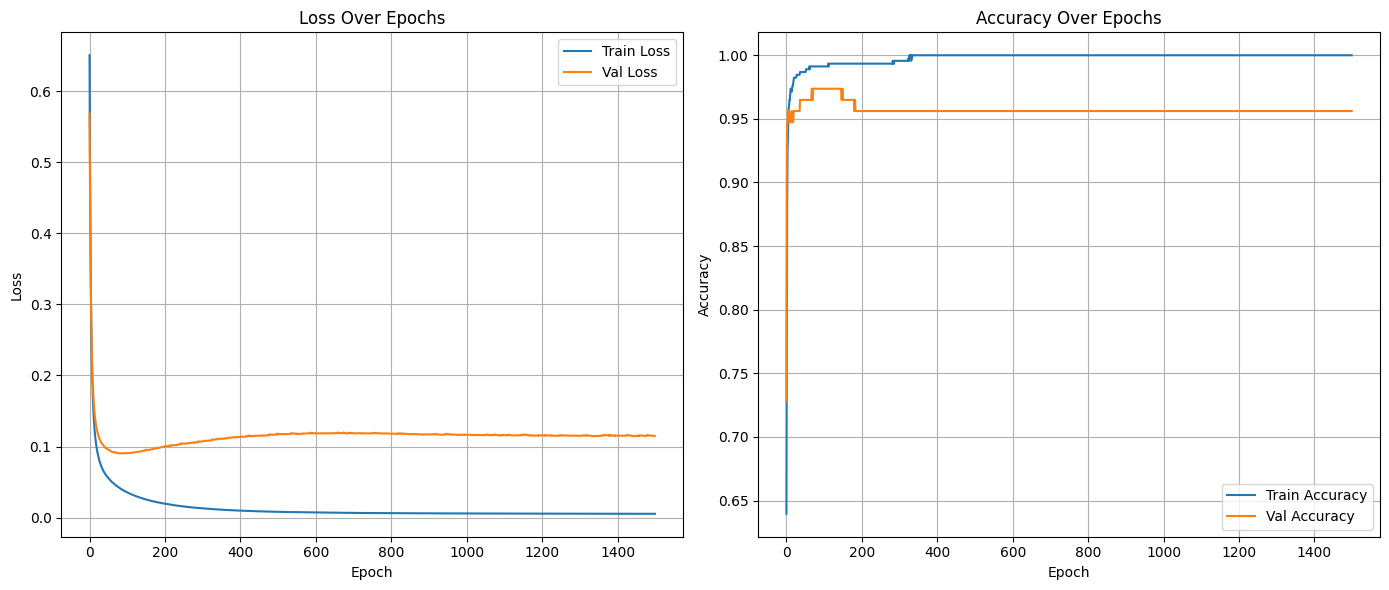

Final train loss: 0.0054
Final train accuracy: 1.0000
Final test loss: 0.1148
Final test accuracy: 0.9561
Generalization gap: 0.1094
Weight L2 norm: 36.6236


In [20]:
# config
epochs = 1500
batch_size = 16
lr = 0.01
l2_lambda = 0.001

# create model
layers = [LinearLayer(in_features=30, out_features=64, initialization=WEIGHT_INIT, l2_lambda=l2_lambda),
ReLU(),
LinearLayer(in_features=64, out_features=32, initialization=WEIGHT_INIT, l2_lambda=l2_lambda),
ReLU(),
LinearLayer(in_features=32, out_features=1, initialization=WEIGHT_INIT, l2_lambda=l2_lambda)]

model1 = Model(layers)

# define loss
loss_fn = BinaryCrossEntropyLoss()

training_cfg_model1 = TrainingConfig(
    epochs=epochs,
    batch_size=batch_size,
    lr=lr,
    scenario_name="L2 Regularization (Model 1)",
    debug_print=True,
    show_plot=True
)

# train and evaluate the model
train_losses, train_accuracies, test_losses, test_accuracies = train_model(
    model1, loss_fn, X_train, y_train, X_test, y_test, training_cfg_model1
)

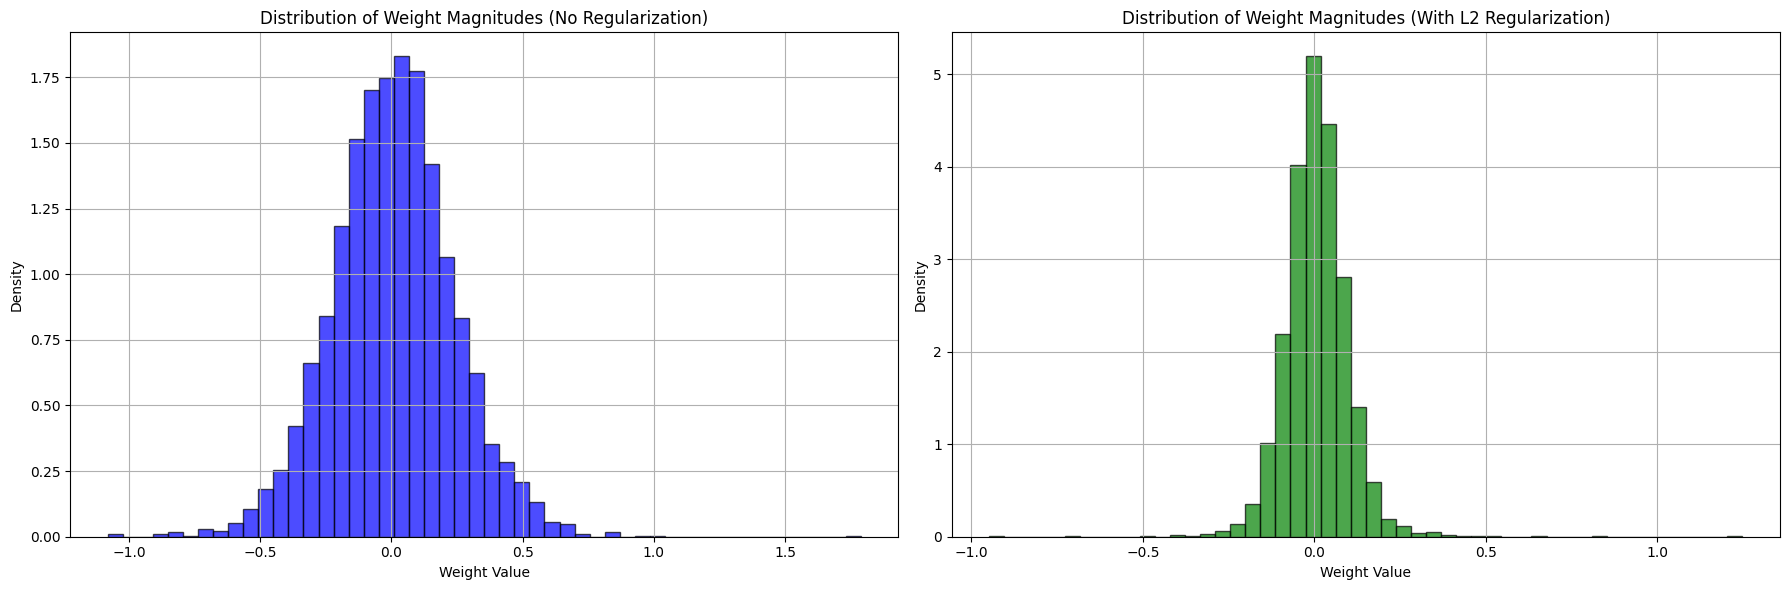

In [21]:
# get weights for model0 no regularization
all_weights_model0 = []
for layer in model0.layers:
  # check for w attribute because I have redefined LinearLayer
  if hasattr(layer, 'w'):
    all_weights_model0.extend(layer.w.flatten())

# get weights for model1 with L2 regularization
all_weights_model1 = []
for layer in model1.layers:
  # check for w attribute because I have redefined LinearLayer
  if hasattr(layer, 'w'):
    all_weights_model1.extend(layer.w.flatten())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#plot model 0
axes[0].hist(all_weights_model0, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Distribution of Weight Magnitudes (No Regularization)')
axes[0].set_xlabel('Weight Value')
axes[0].set_ylabel('Density')
axes[0].grid(True)

# plot model with l2
axes[1].hist(all_weights_model1, bins=50, density=True, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Distribution of Weight Magnitudes (With L2 Regularization)')
axes[1].set_xlabel('Weight Value')
axes[1].set_ylabel('Density')
axes[1].grid(True)

plt.tight_layout()
plt.show()

The effect of L2 regularization is immediately visible: it shrinks the weights toward zero, resulting in a tighter distribution.

# Dropout

Dropout is achieved by setting a random fraction of neuron activations to zero **during training**. This prevents the network from relying too heavily on specific neurons and encourages more robust feature learning.

In practice, this is implemented by applying a random mask to the activations during the forward pass.



## How dropout works

During the forward pass, a random binary mask is applied to the activations:

$$
\tilde{a} = a \cdot m
$$

where:
- $a$ are the original activations
- $m$ is a binary mask sampled from a Bernoulli distribution.

---

### Inverted Dropout

In this implementation, $(p)$ is the drop probability, so the keep probability is $(1 - p)$.

The scaled activation is:

$$\tilde{a} = \frac{a \cdot m}{1-p}$$

---

### Why scaling is needed

Without scaling, the expected value of the activations decreases during training:

$$E[a · m] = (1 - p) · a$$

By dividing by (1 - p), we preserve the expected value:

$$E[(a · m)/(1 - p)] = a$$

If I don't scale in the forward pass, I would have to account for it in the backpropagation, which to me seems a bit more complex.



In [22]:
class Dropout(BaseLayer):
  def __init__(self, p=0.5):
    super().__init__()
    self.p = p  # probability to drop

  def forward(self, x):
    # when in evaluation mode - skip dropout
    if not self.is_training:
        return x

    # create mask (keep = 1, drop = 0)
    self.mask = (np.random.rand(*x.shape) > self.p)

    # inverted dropout
    return x * self.mask / (1 - self.p)

  def backward(self, dout):
    # pass gradient only where neurons survived
    return dout * self.mask / (1 - self.p)

Before I continue experimenting with Dropout, I need to redefine the model class to update layers is_training param.

Dropout Only (Model 2)


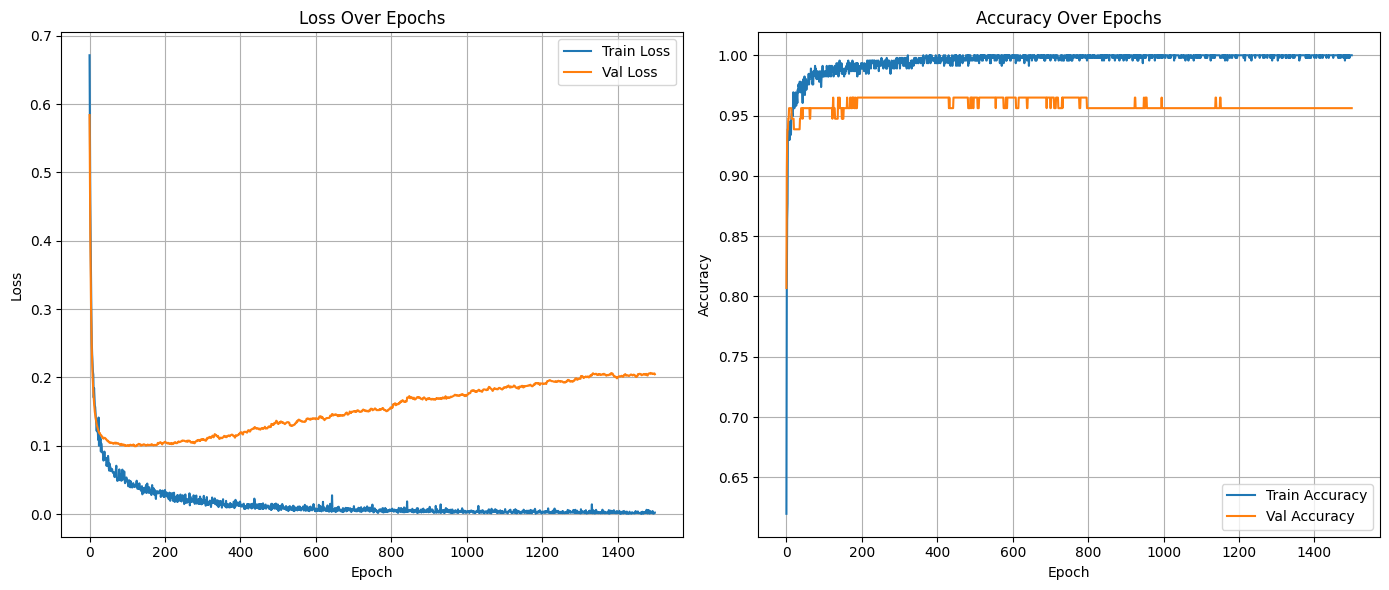

Final train loss: 0.0023
Final train accuracy: 1.0000
Final test loss: 0.2047
Final test accuracy: 0.9561
Generalization gap: 0.2024
Weight L2 norm: 128.3835


In [23]:
epochs = 1500
batch_size = 16
lr = 0.01
l2_lambda = 0.0 # no weight decay, focus on dropout
dropout_p = 0.2

# define the model
layers = [
    LinearLayer(30, 64, initialization=WEIGHT_INIT, l2_lambda=l2_lambda),
    ReLU(),
    Dropout(dropout_p),
    LinearLayer(64, 32, initialization=WEIGHT_INIT, l2_lambda=l2_lambda),
    ReLU(),
    Dropout(dropout_p),
    LinearLayer(32, 1, initialization=WEIGHT_INIT, l2_lambda=l2_lambda),
]

model2 = Model(layers)

loss_fn = BinaryCrossEntropyLoss()

training_cfg_model2 = TrainingConfig(
    epochs=epochs,
    batch_size=batch_size,
    lr=lr,
    scenario_name="Dropout Only (Model 2)",
    debug_print=True,
    show_plot=True
)

# train and evaluate the model
train_losses, train_accuracies, test_losses, test_accuracies = train_model(
    model2, loss_fn, X_train, y_train, X_test, y_test, training_cfg_model2
)

# Dropout conclusions

Dropout makes training harder on purpose, so the model cannot rely too heavily on specific neurons.

> **Important note:** On small tabular datasets, L2 regularization often provides more stable gains than dropout, while dropout can have a more variable effect depending on architecture and training setup.

That doesn't mean that dropout is not an effective technique.

# Experiments run

I will run an experiment to check the effects or l2 and dropout on training.

Starting regularization experiments...
-----------------------------------
1. No Regularization


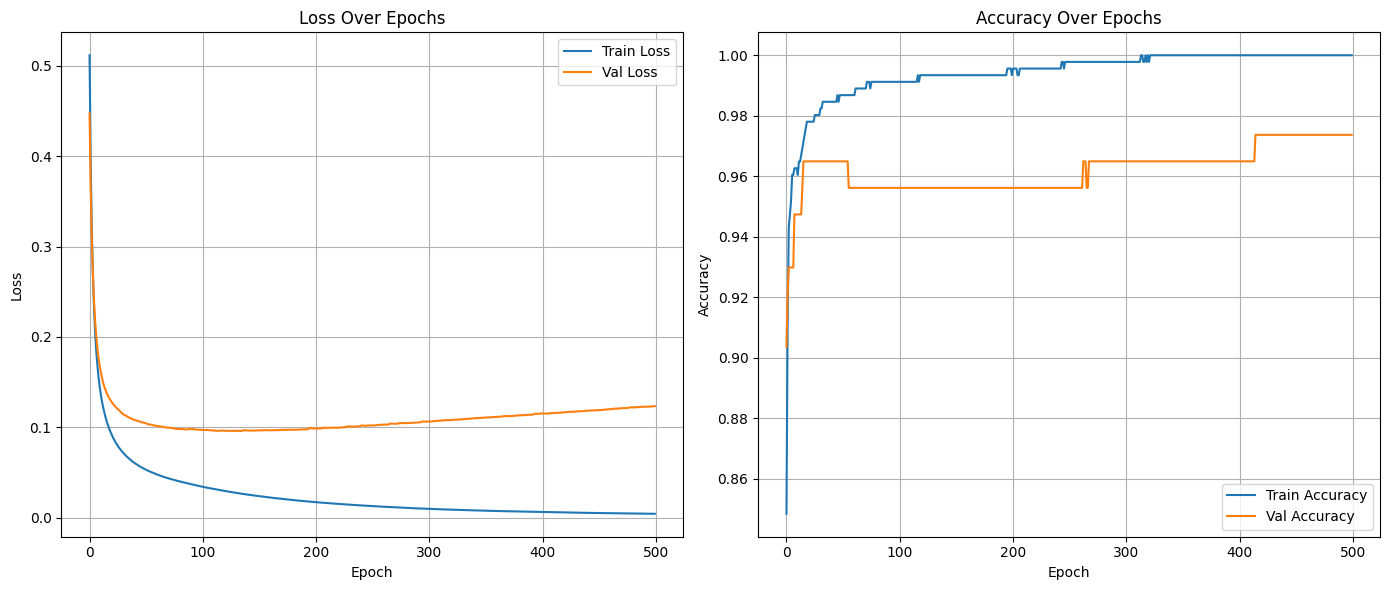

--- 1. No Regularization Results ---
Final train loss: 0.0043
Final train accuracy: 1.0000
Final test loss: 0.1235
Final test accuracy: 0.9737
Generalization gap: 0.1192
Weight L2 norm: 117.1565
------------------------------
2. L2 Regularization Only


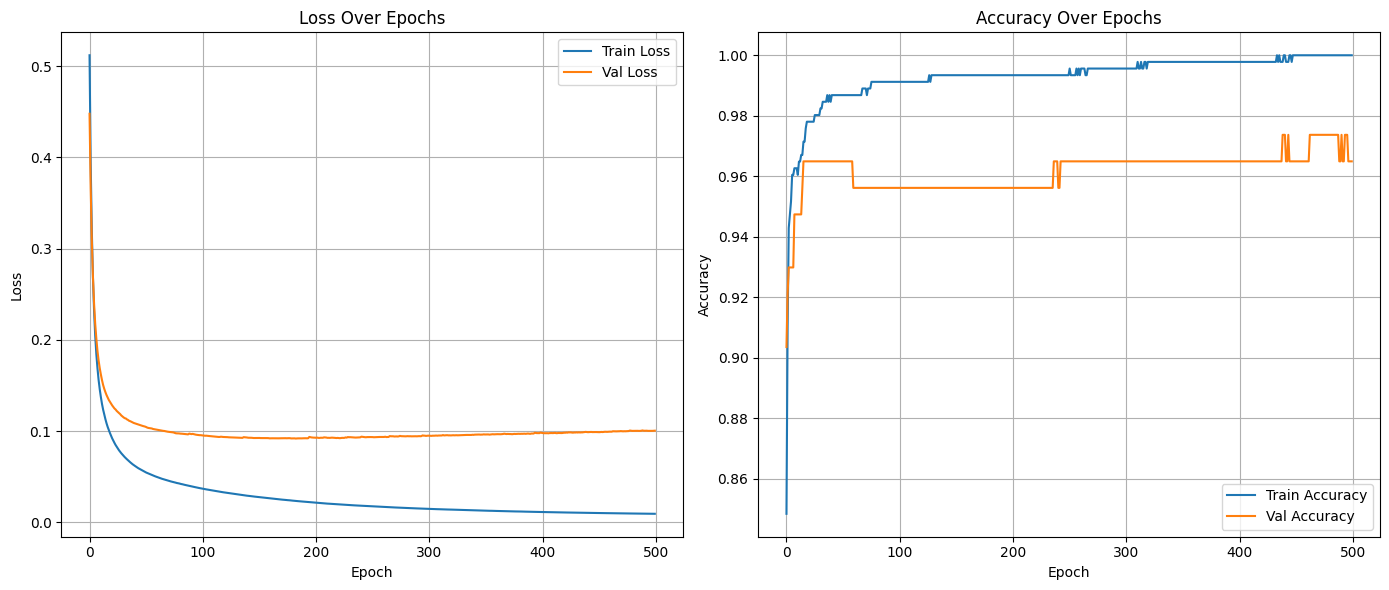

--- 2. L2 Regularization Only Results ---
Final train loss: 0.0092
Final train accuracy: 1.0000
Final test loss: 0.1004
Final test accuracy: 0.9649
Generalization gap: 0.0911
Weight L2 norm: 71.4361
------------------------------
3. Dropout Only


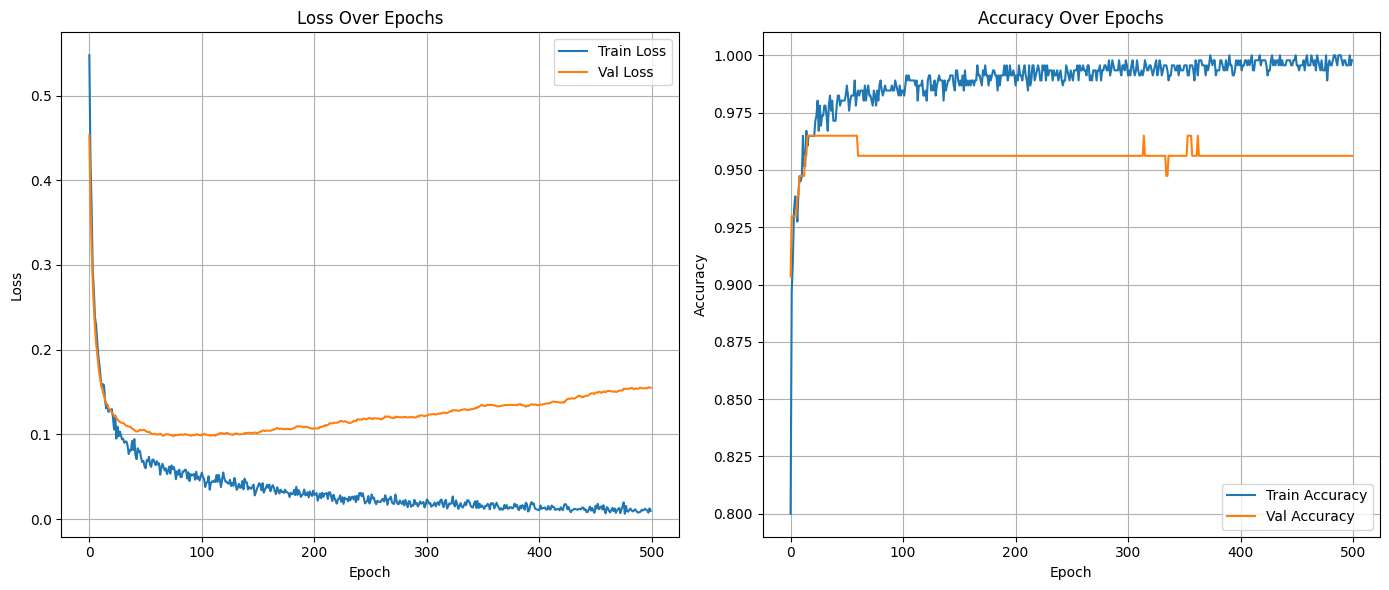

--- 3. Dropout Only Results ---
Final train loss: 0.0098
Final train accuracy: 0.9978
Final test loss: 0.1551
Final test accuracy: 0.9561
Generalization gap: 0.1453
Weight L2 norm: 115.1353
------------------------------
4. Both L2 and Dropout


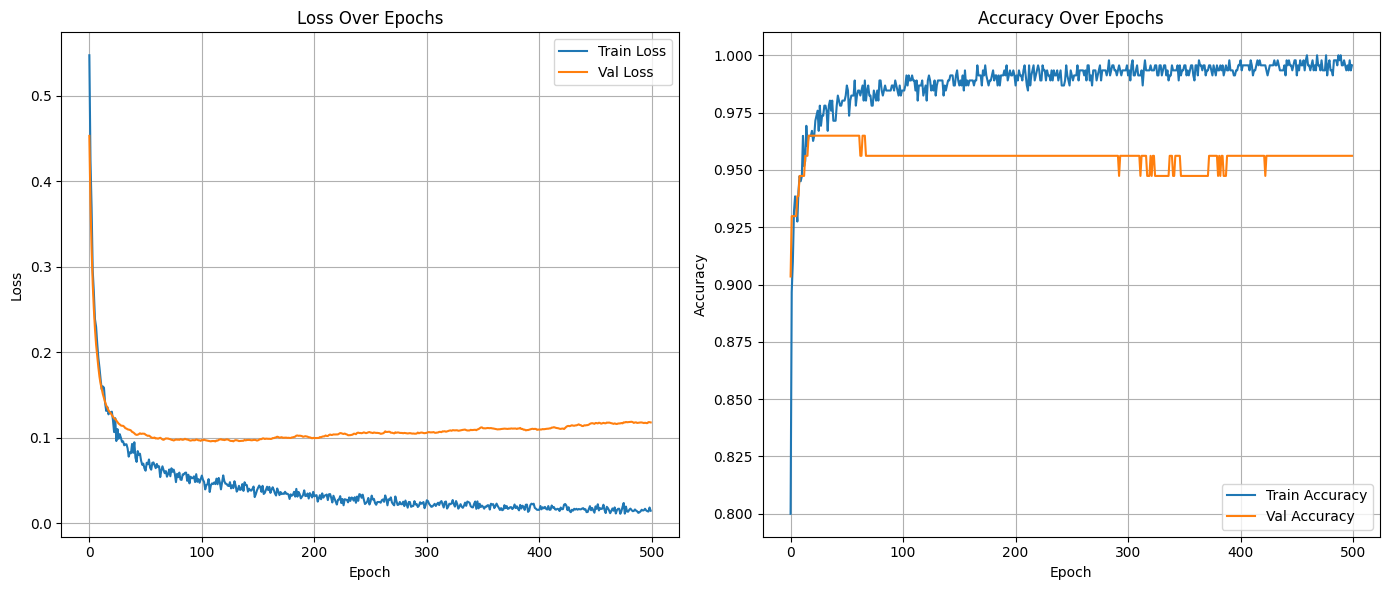

--- 4. Both L2 and Dropout Results ---
Final train loss: 0.0149
Final train accuracy: 0.9956
Final test loss: 0.1181
Final test accuracy: 0.9561
Generalization gap: 0.1032
Weight L2 norm: 70.2268
------------------------------

--- All experiments completed ---


In [24]:
def train_and_plot_scenario(
    layers_config,
    training_config: TrainingConfig,
    l2_lambda,
    dropout_prob,
    X_train, y_train, X_test, y_test
):
  # construct model layers based on configuration
  actual_layers = []
  for layer_def in layers_config:
      if layer_def[0] == 'LinearLayer':
          actual_layers.append(LinearLayer(in_features=layer_def[1], out_features=layer_def[2], initialization=WEIGHT_INIT, l2_lambda=l2_lambda))
      elif layer_def[0] == 'ReLU':
          actual_layers.append(ReLU())
      elif layer_def[0] == 'Dropout':
          if dropout_prob > 0: # minor optimization for no dropout
              actual_layers.append(Dropout(p=dropout_prob))

  model = Model(actual_layers)
  loss_fn = BinaryCrossEntropyLoss()

  train_losses, train_accuracies, test_losses, test_accuracies = train_model(
      model, loss_fn, X_train, y_train, X_test, y_test, training_config
  )

  final_train_loss = train_losses[-1]
  final_train_accuracy = train_accuracies[-1]
  final_test_loss = test_losses[-1]
  final_test_accuracy = test_accuracies[-1]
  generalization_gap = final_test_loss - final_train_loss
  weight_l2_norm = get_total_weight_l2_norm(model)

  print(f"--- {training_config.scenario_name} Results ---")
  print(f"Final train loss: {final_train_loss:.4f}")
  print(f"Final train accuracy: {final_train_accuracy:.4f}")
  print(f"Final test loss: {final_test_loss:.4f}")
  print(f"Final test accuracy: {final_test_accuracy:.4f}")
  print(f"Generalization gap: {generalization_gap:.4f}")
  print(f"Weight L2 norm: {weight_l2_norm:.4f}")
  print("-" * 30)

  return {
      'Scenario': training_config.scenario_name,
      'Train Loss': final_train_loss,
      'Train Acc': final_train_accuracy,
      'Test Loss': final_test_loss,
      'Test Acc': final_test_accuracy,
      'Gen Gap': generalization_gap,
      'L2 Norm': weight_l2_norm
  }

# training parameters
epochs_val = 500
batch_size_val = 16
lr_val = 0.01
in_features = X_train.shape[1]

all_results = []

print("Starting regularization experiments...")
print("-----------------------------------")

# manually set seeds
set_seeds(seed)

# scenario 1 - no regularization
l2_lambda_none = 0.0
dropout_prob_none = 0.0
layers_none = [
    ('LinearLayer', in_features, 64),
    ('ReLU',),
    ('LinearLayer', 64, 32),
    ('ReLU',),
    ('LinearLayer', 32, 1),
]
config_no_reg = TrainingConfig(epochs=epochs_val, batch_size=batch_size_val, lr=lr_val, scenario_name="1. No Regularization", show_plot=True)
results_no_reg = train_and_plot_scenario(layers_none, config_no_reg, l2_lambda_none, dropout_prob_none, X_train, y_train, X_test, y_test)
all_results.append(results_no_reg)

# manually set seeds
set_seeds(seed)

# scenario 2 - L2 Only
l2_lambda_only = 0.001
dropout_prob_only_l2 = 0.0
layers_l2_only = [
    ('LinearLayer', in_features, 64),
    ('ReLU',),
    ('LinearLayer', 64, 32),
    ('ReLU',),
    ('LinearLayer', 32, 1),
]
config_l2_only = TrainingConfig(epochs=epochs_val, batch_size=batch_size_val, lr=lr_val, scenario_name="2. L2 Regularization Only", show_plot=True)
results_l2_only = train_and_plot_scenario(layers_l2_only, config_l2_only, l2_lambda_only, dropout_prob_only_l2, X_train, y_train, X_test, y_test)
all_results.append(results_l2_only)

# manually set seeds
set_seeds(seed)

# scenario 3 - Dropout Only
l2_lambda_dropout_only = 0.0
dropout_prob_only = 0.2
layers_dropout_only = [
    ('LinearLayer', in_features, 64),
    ('ReLU',),
    ('Dropout',),
    ('LinearLayer', 64, 32),
    ('ReLU',),
    ('Dropout',),
    ('LinearLayer', 32, 1),
]
config_dropout_only = TrainingConfig(epochs=epochs_val, batch_size=batch_size_val, lr=lr_val, scenario_name="3. Dropout Only", show_plot=True)
results_dropout_only = train_and_plot_scenario(layers_dropout_only, config_dropout_only, l2_lambda_dropout_only, dropout_prob_only, X_train, y_train, X_test, y_test)
all_results.append(results_dropout_only)

# manually set seeds
set_seeds(seed)

# scenario 4 - both L2 and Dropout
l2_lambda_both = 0.001
dropout_prob_both = 0.2
layers_both = [
    ('LinearLayer', in_features, 64),
    ('ReLU',),
    ('Dropout',),
    ('LinearLayer', 64, 32),
    ('ReLU',),
    ('Dropout',),
    ('LinearLayer', 32, 1),
]
config_both = TrainingConfig(epochs=epochs_val, batch_size=batch_size_val, lr=lr_val, scenario_name="4. Both L2 and Dropout", show_plot=True)
results_both = train_and_plot_scenario(layers_both, config_both, l2_lambda_both, dropout_prob_both, X_train, y_train, X_test, y_test)
all_results.append(results_both)

print("\n--- All experiments completed ---")

In [25]:
results_df = pd.DataFrame(all_results)
print("\n--- Regularization Experiment Summary ---")
print(results_df.to_markdown(index=False, floatfmt=".4f"))


--- Regularization Experiment Summary ---
| Scenario                  |   Train Loss |   Train Acc |   Test Loss |   Test Acc |   Gen Gap |   L2 Norm |
|:--------------------------|-------------:|------------:|------------:|-----------:|----------:|----------:|
| 1. No Regularization      |       0.0043 |      1.0000 |      0.1235 |     0.9737 |    0.1192 |  117.1565 |
| 2. L2 Regularization Only |       0.0092 |      1.0000 |      0.1004 |     0.9649 |    0.0911 |   71.4361 |
| 3. Dropout Only           |       0.0098 |      0.9978 |      0.1551 |     0.9561 |    0.1453 |  115.1353 |
| 4. Both L2 and Dropout    |       0.0149 |      0.9956 |      0.1181 |     0.9561 |    0.1032 |   70.2268 |


Interestingly, the model without regularization achieved the highest test accuracy. However, this highlights an important point: accuracy alone is not always the most informative metric.

The model with L2 regularization shows the smallest generalization gap and the lowest test loss, suggesting better overall generalization. For this dataset, L2 regularization appears to be the more reliable choice, despite not achieving the highest accuracy.

In the next notebook, I will explore additional evaluation metrics to better assess model performance.

> During development, I experimented with several variations beyond what is shown here, including different weight initialization strategies. While these produced interesting results, they significantly increased the notebook's size, so they were omitted for clarity.
